In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [120]:
df = pd.read_csv("titanic_data_updated.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Starter, Train Test and Handling Missing Values

### 1.1 Feature Engineering Starter

In [121]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [122]:
df.isnull().sum()

# df.drop(['Cabin'], axis=1, inplace=True)

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [123]:
x = df.drop(['Survived'], axis=1) # this my features cols
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [124]:
y = df['Survived'] # this my target feature
y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [125]:
x_train, x_test, y_train, y_test =train_test_split(x, y, test_size=0.2, random_state=42)

In [126]:
display(x_train)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


In [127]:
display(y_train)

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [128]:
display(x_test)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,NaN,1,1,15.2458,NaN,C
439,second,male,31.0,0,0,10.5000,NaN,S
840,third,male,20.0,0,0,7.9250,NaN,S
720,second,female,6.0,0,1,33.0000,NaN,S
39,third,female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S
773,third,male,NaN,0,0,7.2250,NaN,C
25,third,female,38.0,1,5,31.3875,NaN,S
84,second,female,17.0,0,0,10.5000,NaN,S


In [129]:
display(y_test)

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: object

## Numerical Value Imputation

In [130]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [131]:
age_mean = x_train['Age'].mean()
x_train['age_mean_imputor'] = x_train['Age'].fillna(age_mean)
x_test['aeg_mean_imputor'] = x_test['Age'].fillna(age_mean)


In [132]:
age_median = x_train['Age'].median()
x_train['age_median_imputor'] = x_train['Age'].fillna(age_median)
x_test['age_median_imputor'] = x_test['Age'].fillna(age_median)

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputor,age_median_imputor
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.0


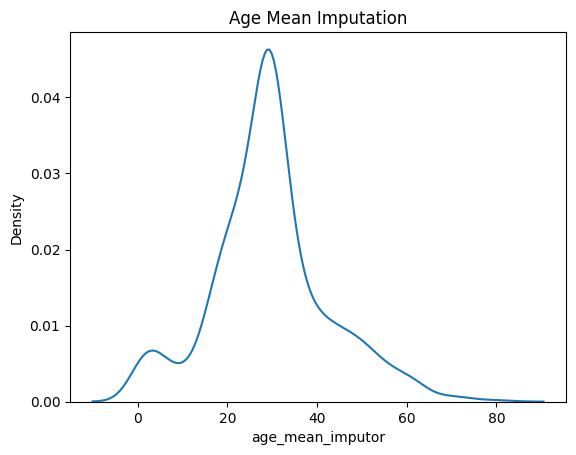

In [133]:
sns.kdeplot(data=x_train, x="age_mean_imputor")
plt.title("Age Mean Imputation")
plt.show()

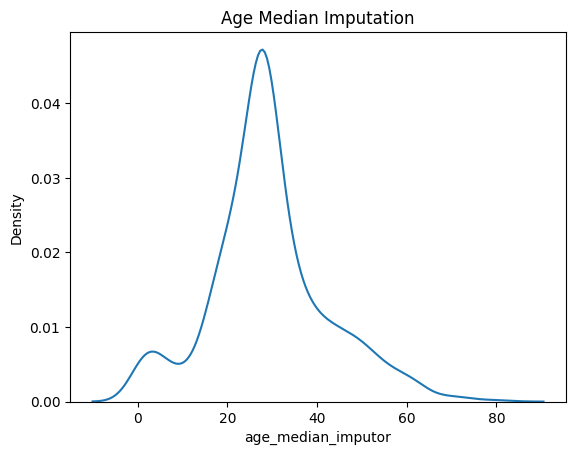

In [134]:
sns.kdeplot(data=x_train, x="age_median_imputor")
plt.title("Age Median Imputation")
plt.show()

### Numerical Missing Values Imputation using Simple Imputer

In [135]:
age_imputer = SimpleImputer(missing_values=np.nan, strategy="mean")

age_imputer.fit(x_train[['Age']])

x_train['Age'] = age_imputer.transform(x_train[['Age']])


x_train.drop(['age_mean_imputor', 'age_median_imputor'], axis=1, inplace=True)
x_train

x_train.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [136]:
x_test['Age'] = age_imputer.transform(x_test[['Age']])

x_test.isnull().sum()

x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,aeg_mean_imputor,age_median_imputor
709,third,male,29.498846,1,1,15.2458,NaN,C,29.498846,28.0
439,second,male,31.000000,0,0,10.5000,NaN,S,31.000000,31.0
840,third,male,20.000000,0,0,7.9250,NaN,S,20.000000,20.0
720,second,female,6.000000,0,1,33.0000,NaN,S,6.000000,6.0
39,third,female,14.000000,1,0,11.2417,NaN,C,14.000000,14.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S,17.000000,17.0
773,third,male,29.498846,0,0,7.2250,NaN,C,29.498846,28.0
25,third,female,38.000000,1,5,31.3875,NaN,S,38.000000,38.0
84,second,female,17.000000,0,0,10.5000,NaN,S,17.000000,17.0


In [137]:
x_test.drop(['aeg_mean_imputor','age_median_imputor'],axis=1,inplace=True)
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


In [138]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

### Categorical Value Imputation with Mode Value

In [139]:
embarked_imputer = SimpleImputer(missing_values=np.nan , strategy='most_frequent')

embarked_imputer.fit(x_train[['Embarked']])

# transform both train and test data

x_train['Embarked']= embarked_imputer.transform(x_train[['Embarked']]).ravel()
x_test['Embarked'] = embarked_imputer.transform(x_test[['Embarked']]).ravel()

In [140]:
x_train.isnull().sum()
x_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

### Categorical Value Imputation with Missing string and Indicator

<Axes: xlabel='Cabin', ylabel='count'>

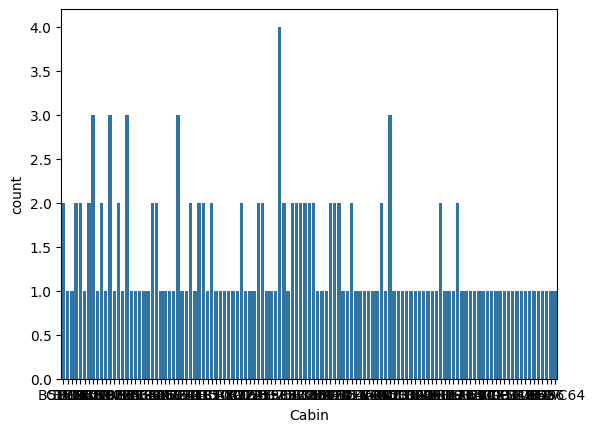

In [141]:
sns.countplot(data = x_train , x=x_train['Cabin'])

### Categorical Value Imputation with Missing string and Indicator

In [142]:
cabin_imputer = SimpleImputer(missing_values=np.nan , strategy='constant',fill_value='Missing',add_indicator=True)

cabin_imputer.fit(x_train[['Cabin']])

# transform both train and test data

x_train[['Cabin','cabin_missing_indicator']]= cabin_imputer.transform(x_train[['Cabin']])
x_test[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(x_test[['Cabin']])

In [143]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False


In [144]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
709,third,male,29.498846,1,1,15.2458,Missing,C,True
439,second,male,31.000000,0,0,10.5000,Missing,S,True
840,third,male,20.000000,0,0,7.9250,Missing,S,True
720,second,female,6.000000,0,1,33.0000,Missing,S,True
39,third,female,14.000000,1,0,11.2417,Missing,C,True
...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True
773,third,male,29.498846,0,0,7.2250,Missing,C,True
25,third,female,38.000000,1,5,31.3875,Missing,S,True
84,second,female,17.000000,0,0,10.5000,Missing,S,True


In [146]:
x_train.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

In [148]:
x_test.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64